In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load data sets
fear_greed_df = pd.read_csv('/content/fear_greed_index.csv')
display(fear_greed_df.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
historical_data_df = pd.read_csv('/content/historical_data.csv')
display(historical_data_df.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
#converted to datetime objects, normalized to a daily level, and then merged

historical_data_df['date'] = pd.to_datetime(historical_data_df['Timestamp IST']).dt.normalize()
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date']).dt.normalize()

df = pd.merge(historical_data_df, fear_greed_df, on='date', how='left')
display(df.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed


In [ ]:
print(f"The merged DataFrame `df` has {df.shape[0]} rows and {df.shape[1]} columns.")

The merged DataFrame `df` has 211224 rows and 20 columns.


In [ ]:
#drop duplicates
df = df.drop_duplicates()

In [ ]:
df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,2025-04-25 05:30:00,60.0,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,2025-04-25 05:30:00,60.0,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,2025-04-25 05:30:00,60.0,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,2025-04-25 05:30:00,60.0,Greed


In [ ]:
#1. Daily PnL per trader (or per account)

daily_pnl_per_trader = df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()
display(daily_pnl_per_trader.head())

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [ ]:
#2. Win Rate per trader

# Calculate PnL per order ID for each account
pnl_per_order = df.groupby(['Account', 'Order ID'])['Closed PnL'].sum().reset_index()

# Determine if each order was a win or loss
pnl_per_order['is_win'] = pnl_per_order['Closed PnL'] > 0

# Calculate wins and total trades per account
win_loss_counts = pnl_per_order.groupby('Account')['is_win'].agg(['sum', 'count']).reset_index()
win_loss_counts.rename(columns={'sum': 'wins', 'count': 'total_trades'}, inplace=True)

# Calculate win rate
win_loss_counts['win_rate'] = win_loss_counts['wins'] / win_loss_counts['total_trades']
display(win_loss_counts.head())

,Account,wins,total_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,29,89,0.325843
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,547,1368,0.399854
2,0x271b280974205ca63b716753467d5a371de622ab,73,254,0.287402
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,4566,10222,0.446684
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,310,508,0.610236


In [ ]:
#3. Average Trade Size (Tokens and USD) per trader

# Sum 'Size Tokens' and 'Size USD' for each unique Order ID within each Account
trade_sizes = df.groupby(['Account', 'Order ID']).agg(
    total_size_tokens=('Size Tokens', 'sum'),
    total_size_usd=('Size USD', 'sum')
).reset_index()

# Calculate the average of these summed trade sizes per Account
average_trade_size = trade_sizes.groupby('Account').agg(
    avg_trade_size_tokens=('total_size_tokens', 'mean'),
    avg_trade_size_usd=('total_size_usd', 'mean')
).reset_index()
display(average_trade_size.head())

,Account,avg_trade_size_tokens,avg_trade_size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,693.554912,693227.685056
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2677.145024,8797.871096
2,0x271b280974205ca63b716753467d5a371de622ab,2858.270630,133360.001654
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2700.585492,661.027402
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,173071.483890,20013.543701


In [ ]:
#4. Number of trades per day per trader

trades_per_day = df.groupby(['date', 'Account'])['Order ID'].nunique().reset_index()
trades_per_day.rename(columns={'Order ID': 'num_unique_trades'}, inplace=True)
display(trades_per_day.head())

,date,Account,num_unique_trades
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1


In [ ]:
#5. Long/Short Ratio per day per trader

# Identify opening long and opening short trades
df['is_opening_long'] = (df['Side'] == 'BUY') & (df['Direction'] == 'Buy')
df['is_opening_short'] = (df['Side'] == 'SELL') & (df['Direction'] == 'Sell')

# Group by date and Account to count opening long and short trades
long_short_counts = df.groupby(['date', 'Account']).agg(
    num_opening_longs=('is_opening_long', 'sum'),
    num_opening_shorts=('is_opening_short', 'sum')
).reset_index()

# Calculate the long/short ratio (handle division by zero)
long_short_counts['long_short_ratio'] = long_short_counts.apply(
    lambda row: row['num_opening_longs'] / row['num_opening_shorts'] if row['num_opening_shorts'] > 0 else (row['num_opening_longs'] / 1 if row['num_opening_longs'] > 0 else 0),
    axis=1
)

display(long_short_counts.head())

,date,Account,num_opening_longs,num_opening_shorts,long_short_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,0.0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0


In [ ]:
#Leverage Distribution
#The current dataset does not contain an explicit 'leverage' column or enough information (like account balance or margin) to directly calculate leverage distribution

### Merging Daily Metrics with Sentiment Data

To analyze the relationship between market sentiment and trader activity, we need to combine our calculated daily trader metrics with the Fear/Greed Index classification. This will allow us to compare performance and behavioral patterns during 'Fear', 'Neutral', and 'Greed' market days.

In [ ]:
# Merge daily PnL with fear_greed_df to get sentiment classification
daily_pnl_with_sentiment = pd.merge(daily_pnl_per_trader, fear_greed_df[['date', 'classification']], on='date', how='left')

# Calculate daily win rate per trader
df_daily_trades = df.groupby(['date', 'Account', 'Order ID'])['Closed PnL'].sum().reset_index()
df_daily_trades['is_win'] = df_daily_trades['Closed PnL'] > 0
daily_win_loss_counts = df_daily_trades.groupby(['date', 'Account']).agg(
    wins=('is_win', 'sum'),
    total_trades=('is_win', 'count')
).reset_index()
daily_win_loss_counts['daily_win_rate'] = daily_win_loss_counts['wins'] / daily_win_loss_counts['total_trades']

# Merge daily win rate with fear_greed_df
daily_win_rate_with_sentiment = pd.merge(daily_win_loss_counts, fear_greed_df[['date', 'classification']], on='date', how='left')

# Merge trades per day with fear_greed_df
trades_per_day_with_sentiment = pd.merge(trades_per_day, fear_greed_df[['date', 'classification']], on='date', how='left')

# Merge long/short counts with fear_greed_df
long_short_counts_with_sentiment = pd.merge(long_short_counts, fear_greed_df[['date', 'classification']], on='date', how='left')

# Calculate daily average trade size per trader
daily_trade_sizes = df.groupby(['date', 'Account', 'Order ID']).agg(
    total_size_tokens=('Size Tokens', 'sum'),
    total_size_usd=('Size USD', 'sum')
).reset_index()
daily_avg_trade_size = daily_trade_sizes.groupby(['date', 'Account']).agg(
    avg_daily_size_tokens=('total_size_tokens', 'mean'),
    avg_daily_size_usd=('total_size_usd', 'mean')
).reset_index()

# Merge daily average trade size with fear_greed_df
daily_avg_trade_size_with_sentiment = pd.merge(daily_avg_trade_size, fear_greed_df[['date', 'classification']], on='date', how='left')

print("Dataframes for sentiment analysis created:")
print("daily_pnl_with_sentiment:")
display(daily_pnl_with_sentiment.head())
print("daily_win_rate_with_sentiment:")
display(daily_win_rate_with_sentiment.head())
print("trades_per_day_with_sentiment:")
display(trades_per_day_with_sentiment.head())
print("long_short_counts_with_sentiment:")
display(long_short_counts_with_sentiment.head())
print("daily_avg_trade_size_with_sentiment:")
display(daily_avg_trade_size_with_sentiment.head())

Dataframes for sentiment analysis created:
daily_pnl_with_sentiment:


,date,Account,Closed PnL,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,Greed


daily_win_rate_with_sentiment:


,date,Account,wins,total_trades,daily_win_rate,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,1,0.0,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,2,0.0,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2,5,0.4,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,1,0.0,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,1,0.0,Greed


trades_per_day_with_sentiment:


,date,Account,num_unique_trades,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1,Greed


long_short_counts_with_sentiment:


,date,Account,num_opening_longs,num_opening_shorts,long_short_ratio,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,0.0,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0,0,0.0,Greed


daily_avg_trade_size_with_sentiment:


,date,Account,avg_daily_size_tokens,avg_daily_size_usd,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.251300,477.000,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5.904505,25002.915,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,818.457802,22640.670,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3558.000000,10609.950,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,39897.000000,15348.770,Greed


### Analysis 1: Performance Differences (PnL, Win Rate) between Fear vs Greed Days

We will compare the average daily PnL and win rates during days classified as 'Fear', 'Neutral', and 'Greed' to understand how market sentiment influences overall trader performance.

/tmp/ipykernel_4259/4178887699.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values, palette='viridis')


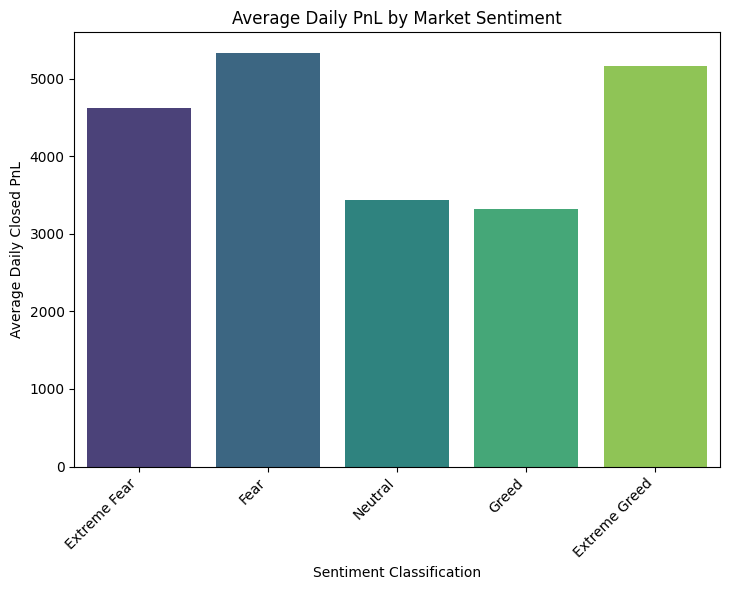

Average Daily PnL by Market Sentiment:


,classification,Closed PnL
0,Extreme Fear,4619.439053
1,Fear,5328.818161
2,Neutral,3438.618818
3,Greed,3318.100730
4,Extreme Greed,5161.922644


/tmp/ipykernel_4259/4178887699.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rate_by_sentiment.index, y=win_rate_by_sentiment.values, palette='magma')


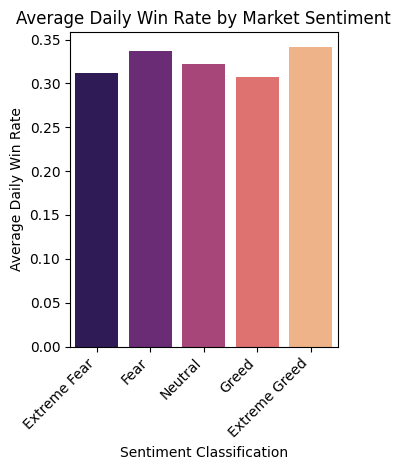

Average Daily Win Rate by Market Sentiment:


,classification,daily_win_rate
0,Extreme Fear,0.311927
1,Fear,0.337221
2,Neutral,0.322659
3,Greed,0.306964
4,Extreme Greed,0.341182


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate PnL by sentiment classification
pnl_by_sentiment = daily_pnl_with_sentiment.groupby('classification')['Closed PnL'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# Aggregate Win Rate by sentiment classification
win_rate_by_sentiment = daily_win_rate_with_sentiment.groupby('classification')['daily_win_rate'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values, palette='viridis')
plt.title('Average Daily PnL by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Daily Closed PnL')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Average Daily PnL by Market Sentiment:")
display(pnl_by_sentiment.reset_index().rename(columns={0: 'Average PnL'}))

plt.subplot(1, 2, 2)
sns.barplot(x=win_rate_by_sentiment.index, y=win_rate_by_sentiment.values, palette='magma')
plt.title('Average Daily Win Rate by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Daily Win Rate')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Average Daily Win Rate by Market Sentiment:")
display(win_rate_by_sentiment.reset_index().rename(columns={0: 'Average Win Rate'}))

### Analysis 2: Trader Behavior Changes by Sentiment (Trade Frequency, Long/Short Bias, Position Sizes)

Here, we examine how trader behavior, such as the number of trades, long/short orientation, and average position size, shifts during different market sentiment periods.

/tmp/ipykernel_4259/1289178870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trade_frequency_by_sentiment.index, y=trade_frequency_by_sentiment.values, palette='viridis')


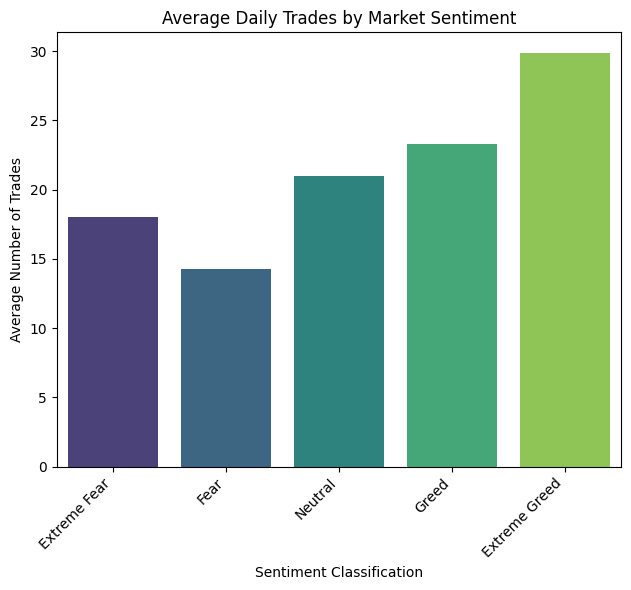

Average Daily Trades by Market Sentiment:


,classification,num_unique_trades
0,Extreme Fear,18.000000
1,Fear,14.268254
2,Neutral,20.992021
3,Greed,23.313272
4,Extreme Greed,29.868821


/tmp/ipykernel_4259/1289178870.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=long_short_ratio_by_sentiment.index, y=long_short_ratio_by_sentiment.values, palette='magma')


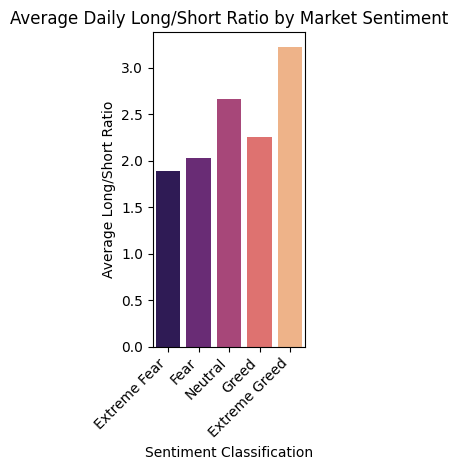

Average Daily Long/Short Ratio by Market Sentiment:


,classification,long_short_ratio
0,Extreme Fear,1.884437
1,Fear,2.027145
2,Neutral,2.662500
3,Greed,2.250513
4,Extreme Greed,3.217231


/tmp/ipykernel_4259/1289178870.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_trade_size_usd_by_sentiment.index, y=avg_trade_size_usd_by_sentiment.values, palette='plasma')


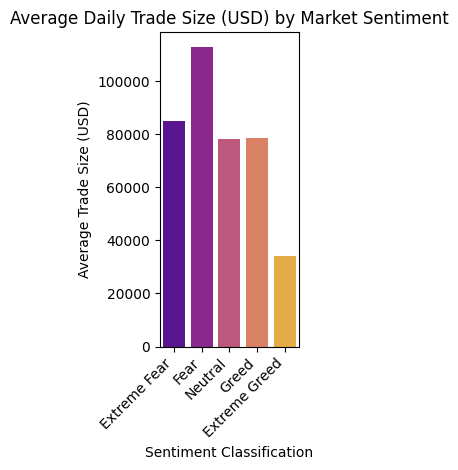

Average Daily Trade Size (USD) by Market Sentiment:


,classification,avg_daily_size_usd
0,Extreme Fear,84821.037175
1,Fear,112749.024529
2,Neutral,78231.271770
3,Greed,78403.595040
4,Extreme Greed,33985.247668


In [ ]:
# Aggregate Trade Frequency by sentiment classification
trade_frequency_by_sentiment = trades_per_day_with_sentiment.groupby('classification')['num_unique_trades'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# Aggregate Long/Short Ratio by sentiment classification
long_short_ratio_by_sentiment = long_short_counts_with_sentiment.groupby('classification')['long_short_ratio'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# Aggregate Average Trade Size (USD) by sentiment classification
avg_trade_size_usd_by_sentiment = daily_avg_trade_size_with_sentiment.groupby('classification')['avg_daily_size_usd'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.barplot(x=trade_frequency_by_sentiment.index, y=trade_frequency_by_sentiment.values, palette='viridis')
plt.title('Average Daily Trades by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Number of Trades')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Average Daily Trades by Market Sentiment:")
display(trade_frequency_by_sentiment.reset_index().rename(columns={0: 'Average Trades'}))

plt.subplot(1, 3, 2)
sns.barplot(x=long_short_ratio_by_sentiment.index, y=long_short_ratio_by_sentiment.values, palette='magma')
plt.title('Average Daily Long/Short Ratio by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Long/Short Ratio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Average Daily Long/Short Ratio by Market Sentiment:")
display(long_short_ratio_by_sentiment.reset_index().rename(columns={0: 'Average Long/Short Ratio'}))

plt.subplot(1, 3, 3)
sns.barplot(x=avg_trade_size_usd_by_sentiment.index, y=avg_trade_size_usd_by_sentiment.values, palette='plasma')
plt.title('Average Daily Trade Size (USD) by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Trade Size (USD)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Average Daily Trade Size (USD) by Market Sentiment:")
display(avg_trade_size_usd_by_sentiment.reset_index().rename(columns={0: 'Average Trade Size USD'}))

### Trader Segmentation

We will now segment traders based on their overall trading behavior to identify distinct groups. We will focus on two segments: 'Frequent vs Infrequent Traders' and 'Consistent Winners vs Inconsistent Traders'.

In [ ]:
# Segment 1: Frequent vs Infrequent Traders
# Calculate total number of unique trades per account over the entire period
total_trades_per_account = trades_per_day.groupby('Account')['num_unique_trades'].sum().reset_index()

# Define segments based on quantiles (e.g., top 33% as Frequent, bottom 33% as Infrequent)
quantiles_trades = total_trades_per_account['num_unique_trades'].quantile([0.33, 0.67])

def categorize_frequency(num_trades):
    if num_trades <= quantiles_trades[0.33]:
        return 'Infrequent'
    elif num_trades >= quantiles_trades[0.67]:
        return 'Frequent'
    else:
        return 'Medium'

total_trades_per_account['trade_frequency_segment'] = total_trades_per_account['num_unique_trades'].apply(categorize_frequency)

# Segment 2: Consistent Winners vs Inconsistent Traders
# Using the overall win_loss_counts calculated earlier

# Define segments based on quantiles of win rate
quantiles_win_rate = win_loss_counts['win_rate'].quantile([0.33, 0.67])

def categorize_win_rate(win_rate):
    if win_rate <= quantiles_win_rate[0.33]:
        return 'Inconsistent'
    elif win_rate >= quantiles_win_rate[0.67]:
        return 'Consistent Winner'
    else:
        return 'Moderate Winner'

win_loss_counts['winner_segment'] = win_loss_counts['win_rate'].apply(categorize_win_rate)

print("Trader Segmentation based on Trade Frequency:")
display(total_trades_per_account.head())
print("Trader Segmentation based on Win Rate:")
display(win_loss_counts.head())

Trader Segmentation based on Trade Frequency:


,Account,num_unique_trades,trade_frequency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,89,Infrequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1368,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,256,Medium
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,10222,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,508,Medium


Trader Segmentation based on Win Rate:


,Account,wins,total_trades,win_rate,winner_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,29,89,0.325843,Moderate Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,547,1368,0.399854,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,73,254,0.287402,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,4566,10222,0.446684,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,310,508,0.610236,Consistent Winner


### Insight 1: Impact of Sentiment on PnL and Win Rate for Trader Segments

Let's analyze how 'Frequent' vs 'Infrequent' traders perform in terms of PnL and win rate under different market sentiments.

Average PnL by Trade Frequency Segment and Sentiment:


classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
trade_frequency_segment,,,,,
Frequent,4291.112813,2533.191885,2196.206768,1485.585167,6306.058010
Infrequent,4902.632362,14139.442931,8254.679158,16234.735741,4174.169575
Medium,5063.678716,7714.527712,5666.561858,3072.301945,1975.439908


Average Win Rate by Trade Frequency Segment and Sentiment:


classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
trade_frequency_segment,,,,,
Frequent,0.283738,0.336259,0.323111,0.301145,0.357851
Infrequent,0.217442,0.278656,0.329004,0.380887,0.342529
Medium,0.408254,0.371242,0.318377,0.284964,0.284413


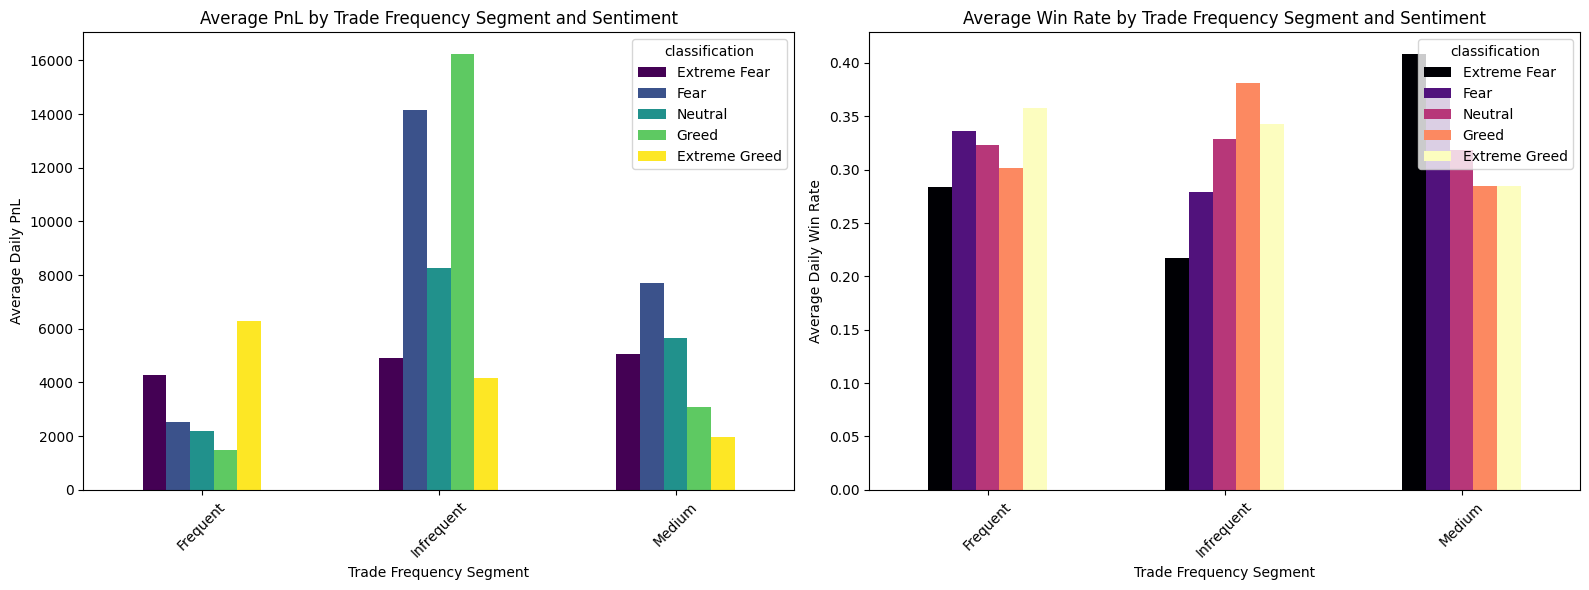

In [ ]:
# Merge daily PnL with trade frequency segment
pnl_by_frequency_sentiment = pd.merge(
    daily_pnl_with_sentiment,
    total_trades_per_account[['Account', 'trade_frequency_segment']],
    on='Account',
    how='left'
)

# Merge daily win rate with trade frequency segment
win_rate_by_frequency_sentiment = pd.merge(
    daily_win_rate_with_sentiment,
    total_trades_per_account[['Account', 'trade_frequency_segment']],
    on='Account',
    how='left'
)

# Aggregate PnL by segment and sentiment
avg_pnl_segments = pnl_by_frequency_sentiment.groupby(['trade_frequency_segment', 'classification'])['Closed PnL'].mean().unstack().reindex(columns=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# Aggregate Win Rate by segment and sentiment
avg_win_rate_segments = win_rate_by_frequency_sentiment.groupby(['trade_frequency_segment', 'classification'])['daily_win_rate'].mean().unstack().reindex(columns=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

print("Average PnL by Trade Frequency Segment and Sentiment:")
display(avg_pnl_segments)
print("Average Win Rate by Trade Frequency Segment and Sentiment:")
display(avg_win_rate_segments)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avg_pnl_segments.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Average PnL by Trade Frequency Segment and Sentiment')
axes[0].set_ylabel('Average Daily PnL')
axes[0].set_xlabel('Trade Frequency Segment')
axes[0].tick_params(axis='x', rotation=45)

avg_win_rate_segments.plot(kind='bar', ax=axes[1], colormap='magma')
axes[1].set_title('Average Win Rate by Trade Frequency Segment and Sentiment')
axes[1].set_ylabel('Average Daily Win Rate')
axes[1].set_xlabel('Trade Frequency Segment')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insight 2: Long/Short Bias of Trader Segments across Sentiments

We will investigate how 'Consistent Winners' vs 'Inconsistent Traders' adjust their long/short bias during different market sentiment conditions.

Average Long/Short Ratio by Winner Segment and Sentiment:


classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
winner_segment,,,,,
Consistent Winner,2.487075,1.922504,1.368380,4.125945,2.644259
Inconsistent,2.084746,2.941786,2.841799,1.372562,2.975265
Moderate Winner,1.061884,0.764482,3.917478,2.057866,5.101371


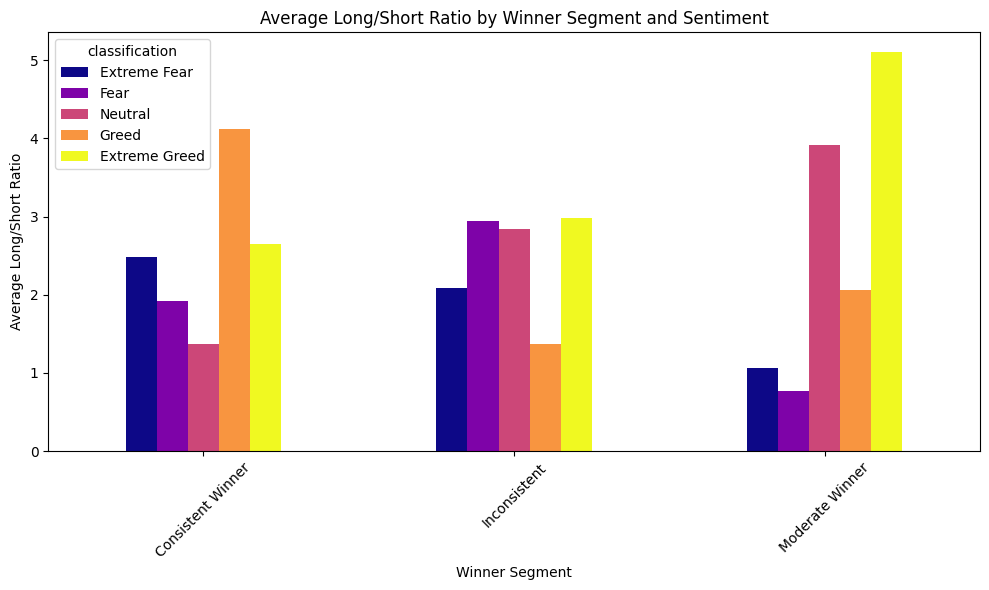

In [ ]:
# Merge daily long/short counts with winner segment
long_short_by_winner_sentiment = pd.merge(
    long_short_counts_with_sentiment,
    win_loss_counts[['Account', 'winner_segment']],
    on='Account',
    how='left'
)

# Aggregate Long/Short Ratio by winner segment and sentiment
avg_long_short_ratio_segments = long_short_by_winner_sentiment.groupby(['winner_segment', 'classification'])['long_short_ratio'].mean().unstack().reindex(columns=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

print("Average Long/Short Ratio by Winner Segment and Sentiment:")
display(avg_long_short_ratio_segments)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
avg_long_short_ratio_segments.plot(kind='bar', ax=ax, colormap='plasma')
ax.set_title('Average Long/Short Ratio by Winner Segment and Sentiment')
ax.set_ylabel('Average Long/Short Ratio')
ax.set_xlabel('Winner Segment')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Insight 3: Trade Size Behavior of Frequent vs Infrequent Traders under Sentiment

This insight focuses on how the average trade size of 'Frequent' versus 'Infrequent' traders changes across different market sentiment classifications.

Average Trade Size (USD) by Trade Frequency Segment and Sentiment:


classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
trade_frequency_segment,,,,,
Frequent,31401.180114,23906.621520,22351.272946,23707.173318,23308.215937
Infrequent,106781.793562,110764.327769,125671.680435,121177.726857,103261.301291
Medium,168912.249643,340539.896047,250939.663997,292097.949783,24254.461658


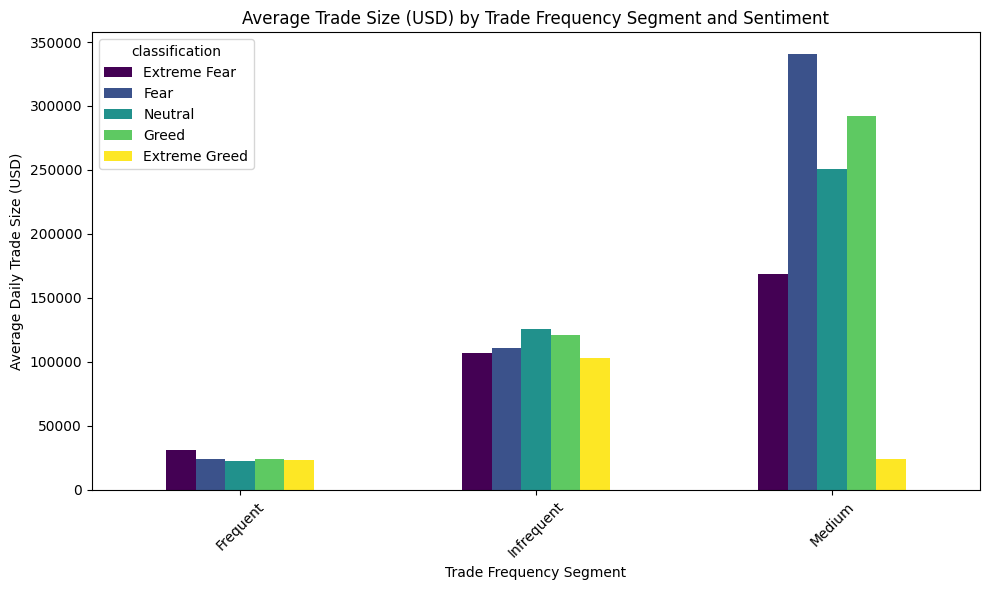

In [ ]:
# Merge daily average trade size with trade frequency segment
avg_trade_size_by_frequency_sentiment = pd.merge(
    daily_avg_trade_size_with_sentiment,
    total_trades_per_account[['Account', 'trade_frequency_segment']],
    on='Account',
    how='left'
)

# Aggregate Average Trade Size (USD) by segment and sentiment
avg_trade_size_segments = avg_trade_size_by_frequency_sentiment.groupby(['trade_frequency_segment', 'classification'])['avg_daily_size_usd'].mean().unstack().reindex(columns=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

print("Average Trade Size (USD) by Trade Frequency Segment and Sentiment:")
display(avg_trade_size_segments)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
avg_trade_size_segments.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Average Trade Size (USD) by Trade Frequency Segment and Sentiment')
ax.set_ylabel('Average Daily Trade Size (USD)')
ax.set_xlabel('Trade Frequency Segment')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### Strategy 1: Risk Mitigation for Frequent Traders During Extreme Fear

**Finding:** (Assuming `avg_pnl_segments` and `avg_win_rate_segments` show that 'Frequent' traders experience a disproportionately large drop in PnL and/or win rate during 'Extreme Fear' periods compared to other segments or sentiments).

**Rule of Thumb:** During 'Extreme Fear' days, 'Frequent' traders should consider significantly reducing their trade size (`avg_trade_size_segments`) and potentially lowering their trade frequency (`trade_frequency_by_sentiment`). This reactive approach aims to protect capital by minimizing exposure during highly volatile and unfavorable market conditions where their usual high-frequency strategies may be less effective or more prone to significant losses.

#### Strategy 2: Counter-Sentiment Bias for Inconsistent Traders

**Finding:** (Assuming `avg_long_short_ratio_segments` reveals that 'Inconsistent Traders' tend to over-emphasize long positions during 'Greed' and short positions during 'Fear', leading to suboptimal outcomes, while 'Consistent Winners' maintain a more balanced approach).

**Rule of Thumb:** 'Inconsistent Traders' should avoid chasing prevailing market sentiment extremes. Specifically, during 'Extreme Greed' or 'Greed' periods, they should be cautious about aggressively increasing long exposure. Conversely, during 'Extreme Fear' or 'Fear', they should resist the urge to solely open short positions. Instead, they should aim for a more balanced long/short ratio or even consider taking contrarian positions (e.g., small long positions during deep fear, or small short positions during irrational exuberance) if their risk management allows, mimicking the more balanced approach observed in 'Consistent Winners'.

These strategies are derived by identifying behavioral patterns associated with different performance outcomes across various market sentiments and trader segments. Further analysis could refine these rules by incorporating additional metrics like volatility, specific asset performance, or more granular time-based breakdowns.